# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Описание данных**

- airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
- balcony — число балконов
- ceiling_height — высота потолков (м)
- cityCenters_nearest — расстояние до центра города (м)
- days_exposition — сколько дней было размещено объявление (от публикации до снятия)
- first_day_exposition — дата публикации
- floor — этаж
- floors_total — всего этажей в доме
- is_apartment — апартаменты (булев тип)
- kitchen_area — площадь кухни в квадратных метрах (м²)
- last_price — цена на момент снятия с публикации
- living_area — жилая площадь в квадратных метрах (м²)
- locality_name — название населённого пункта
- open_plan — свободная планировка (булев тип)
- parks_around3000 — число парков в радиусе 3 км
- parks_nearest — расстояние до ближайшего парка (м)
- ponds_around3000 — число водоёмов в радиусе 3 км
- ponds_nearest — расстояние до ближайшего водоёма (м)
- rooms — число комнат
- studio — квартира-студия (булев тип)
- total_area — общая площадь квартиры в квадратных метрах (м²)
- total_images — число фотографий квартиры в объявлении

### Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import numpy as np


In [2]:
#Чтобы видеть все столбцы
pd.set_option('display.max_columns', None)

In [ ]:
try:
    pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
total_images,23699.0,9.858475e+00,5.682529e+00,0.0,6.00,9.00,14.0,50.0
last_price,23699.0,6.541549e+06,1.088701e+07,12190.0,3400000.00,4650000.00,6800000.0,763000000.0
total_area,23699.0,6.034865e+01,3.565408e+01,12.0,40.00,52.00,69.9,900.0
rooms,23699.0,2.070636e+00,1.078405e+00,0.0,1.00,2.00,3.0,19.0
ceiling_height,14504.0,2.771499e+00,1.261056e+00,1.0,2.52,2.65,2.8,100.0
floors_total,23613.0,1.067382e+01,6.597173e+00,1.0,5.00,9.00,16.0,60.0
living_area,21796.0,3.445785e+01,2.203045e+01,2.0,18.60,30.00,42.3,409.7
floor,23699.0,5.892358e+00,4.885249e+00,1.0,2.00,4.00,8.0,33.0
kitchen_area,21421.0,1.056981e+01,5.905438e+00,1.3,7.00,9.10,12.0,112.0
balcony,12180.0,1.150082e+00,1.071300e+00,0.0,0.00,1.00,2.0,5.0


In [6]:
data.duplicated().sum()

0

In [7]:
data.isna().sum()


total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

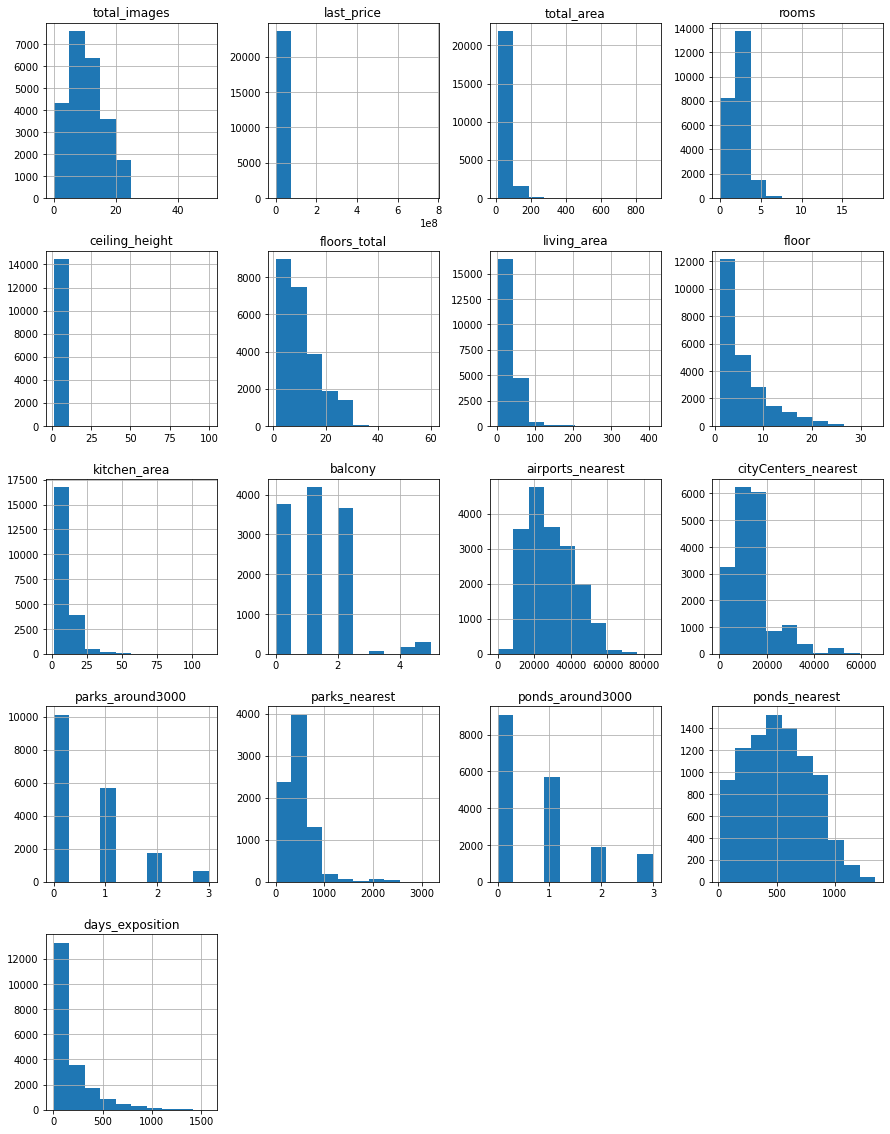

In [8]:
data.hist(figsize=(15, 20));

Изучив датасет видим, что явных дубликатов нет, но много пропущенных значений, есть аномальные значения, но в небольшом количестве, судя по гистограмам. Не везде логичный тип данных в столбцах. Будем исследовать.

### Выполните предобработку данных

Приведём названия стобцов к единому стилю snake_case

In [9]:
data.columns


Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

In [10]:
data.columns = ['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'city_centers_nearest',
       'parks_around_3000', 'parks_nearest', 'ponds_around_3000',
       'ponds_nearest', 'days_exposition']
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Столбец "first_day_exposition" преобразуем к datetime.

In [11]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')


data.head()


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Много пропусков в столбце 'balcony', если продавец не указал число балконов, то, скорее всего, в его квартире их нет, поэтому заполним пропуски нулями. Заодно изменим тип данных на целочисленный, так как число балконов не может быть дробным.

In [12]:
data['balcony'] = data['balcony'].fillna(0).astype(int)


В столбце 'is_apartment' пропущенные значения, видимо, тоже означают, что это не апартаменты, заменим их на False. Большое количество пропусков говорит о том, что они неслучайны и могли возникнуть из-за неверного заполнения данных пользователями, ошибки на этапе выгрузки данных, либо в результате неправильного объединения таблиц.

In [13]:
data['is_apartment'] = data['is_apartment'].fillna(False)

Поработаем с высотой потолков 'ceiling_height', много пропусков, нужно с ними разобраться.

In [14]:
#Найдём среднее значение высоты потолков с ограничением, отсеивающим явно аномальные значения
ceil = data.query('ceiling_height > 2 and ceiling_height < 10')['ceiling_height'].mean()
ceil

2.728826132042862

In [15]:
#Заменим аномальные значения на средние
data.loc[data['ceiling_height'] < 2, 'ceiling_height'] = ceil
data.loc[data['ceiling_height'] > 10, 'ceiling_height'] = ceil

In [16]:
#Проверим как получилось
data.query('ceiling_height < 2 and ceiling_height > 10')['ceiling_height'].sum()

0.0

In [17]:
#А пропуски заменим медианным значением
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())


В столбцах floors_total и locality_name очень мало пропусков по отношению к общему количеству данных, кроме того, как узнать этажность и название поселения из других данных не понятно, поэтому оставим как есть.

Для заполнения следующих столбцов проверим с какими другими стобцами с числовыми значениями они коррелируют, может быть удастся заполнить по корреляции.

In [18]:
data.select_dtypes(include=[np.number]).corr().sort_values(by='living_area', ascending=False)['living_area']


living_area             1.000000
total_area              0.939537
rooms                   0.845977
last_price              0.566492
kitchen_area            0.428674
ceiling_height          0.365250
parks_around_3000       0.184453
ponds_around_3000       0.148933
days_exposition         0.142454
total_images            0.104780
balcony                -0.014772
parks_nearest          -0.050167
airports_nearest       -0.057912
ponds_nearest          -0.081674
floor                  -0.097210
floors_total           -0.169311
city_centers_nearest   -0.231368
Name: living_area, dtype: float64

In [19]:
data.select_dtypes(include=[np.number]).corr().sort_values(by='kitchen_area', ascending=False)['kitchen_area']

kitchen_area            1.000000
total_area              0.609121
last_price              0.519869
living_area             0.428674
ceiling_height          0.322679
rooms                   0.269945
floors_total            0.163944
ponds_around_3000       0.150148
floor                   0.135531
total_images            0.104756
days_exposition         0.100586
parks_around_3000       0.087503
balcony                 0.045271
parks_nearest           0.029641
airports_nearest        0.008200
ponds_nearest          -0.105223
city_centers_nearest   -0.190049
Name: kitchen_area, dtype: float64

Заменим пустые значения жилой площади и площади кухни с помощью отношения их средней к общей средней площади из имеющихся данных т.к. наибольшая корреляция у них с этим столбцом:

In [20]:
living = data['living_area'].mean() / data['total_area'].mean()
kitchen = data['kitchen_area'].mean() / data['total_area'].mean()
data['living_area'] = data['living_area'].fillna(living * data['total_area'])
data['kitchen_area'] = data['kitchen_area'].fillna(kitchen * data['total_area'])


Поищем неявные дубликаты в названиях поселений.

In [21]:
data['locality_name'].sort_values().unique()

array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалёво',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Янино-1',
       'городской посёлок Будогощь', 'городской посёлок Виллози',
       'городской посёлок Лесогорский', 'городской посёлок Мга',
       'городской посёлок Назия', 'городской посёлок Новоселье',
       'городской посёлок Павлово', 'городской посёлок Рощино',
       'городской посёлок Свирьстрой', 'городской посёлок Совет

In [22]:
len(data.locality_name.sort_values().unique())

365

Заметил большое количество неявных дубликатов, есть идея удалить названия вида поселений, т.к. неявные дубликаты имеют разный вид поселения, но одинаковое название, и являются одним и тем же поселением, я проверил. Датасет предоставляет такую возможность т.к. виды поселений написаны со строчной буквы, а названия с большой. Создадим функцию которая выберет слова в которых есть не только строчные буквы - это и будут названия поселений.

In [23]:
len(data.locality_name.sort_values().unique())

365

In [24]:
#Изменим тип данных в столбце на строчный, чтобы функция работала
data['locality_name'] = data['locality_name'].astype(str)

In [25]:
#Создадим функцию posel для обработки названий поселений
def posel (row):
    return ' '.join(word for word in row.split(' ') if not(word.islower()))

In [26]:
#Применяем функцию с столбцу locality_name
data.locality_name = data.locality_name.apply(posel)


In [27]:
data['locality_name'].sort_values().unique()

array(['', 'Агалатово', 'Александровская', 'Алексеевка', 'Аннино', 'Аро',
       'Барышево', 'Батово', 'Бегуницы', 'Белогорка', 'Белоостров',
       'Бокситогорск', 'Большая Вруда', 'Большая Ижора',
       'Большая Пустомержа', 'Большие Колпаны', 'Большое Рейзино',
       'Большой Сабск', 'Бор', 'Борисова Грива', 'Бугры', 'Будогощь',
       'Ваганово', 'Важины', 'Вартемяги', 'Вахнова Кара', 'Вещево',
       'Виллози', 'Вознесенье', 'Возрождение', 'Войсковицы', 'Войскорово',
       'Володарское', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Вырица', 'Выскатка', 'Высокоключевой', 'Высоцк', 'Гаврилово',
       'Гарболово', 'Гатчина', 'Гладкое', 'Глажево', 'Глебычево',
       'Глинка', 'Гончарово', 'Горбунки', 'Гостилицы', 'Громово',
       'Дзержинского', 'Дружная Горка', 'Дружноселье', 'Дубровка',
       'Елизаветино', 'Ефимовский', 'Жилгородок', 'Жилпосёлок', 'Житково',
       'Заводской', 'Заклинье', 'Заневка', 'Запорожское', 'Зеленогорск',
       'Зимитицы', 'Ивангород', 'Изв

In [28]:
len(data.locality_name.sort_values().unique())

306

Избавились аж от 59 дубликатов.

Поработаем с аномальными значениями:

Проанализируем столбец last_price на наличие выбросов:

In [29]:
data.last_price.describe()

count    2.369900e+04
mean     6.541549e+06
std      1.088701e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64

<AxesSubplot:>

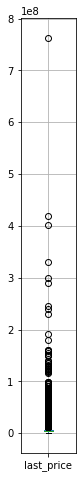

In [30]:
#Построим диаграмму размаха
data.boxplot(column='last_price', grid=True, figsize=(1, 8))


Судя по диаграмме значения более 100 млн являются редкими, и их можно отбросить.

In [31]:
data = data.query('last_price <= 100000000').reset_index(drop=True)

Проанализируем столбец total_area на наличие выбросов:

In [32]:
data.total_area.describe()

count    23662.000000
mean        59.928048
std         33.471517
min         12.000000
25%         40.000000
50%         52.000000
75%         69.600000
max        590.000000
Name: total_area, dtype: float64

<AxesSubplot:>

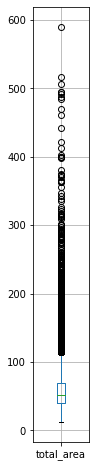

In [33]:
#Построим диаграмму размаха
data.boxplot(column='total_area', grid=True, figsize=(1, 8))

Судя по диаграмме значения более 400 являются редкими, и их можно отбросить.

In [34]:
data = data.query('total_area <= 400').reset_index(drop=True)

Проанализируем столбец rooms на наличие выбросов:

In [35]:
data.rooms.describe()

count    23648.000000
mean         2.063388
std          1.063191
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

<AxesSubplot:>

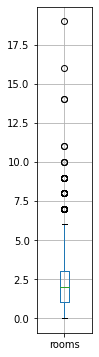

In [36]:
#Построим диаграмму размаха
data.boxplot(column='rooms', grid=True, figsize=(1, 6))

Судя по диаграмме значения более 10 являются редкими, и их можно отбросить.

In [37]:
data=data.query('rooms <= 10').reset_index(drop=True)

Проанализируем столбец floors_total:

In [38]:
data.floors_total.describe()

count    23556.000000
mean        10.682331
std          6.599917
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

<AxesSubplot:>

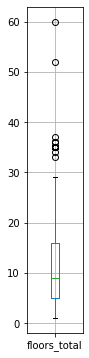

In [39]:
#Построим диаграмму размаха
data.boxplot(column='floors_total', grid=True, figsize=(1, 6))

Судя по диаграмме значения более 40 являются редкими, и их можно отбросить.

In [40]:
data = data.query('floors_total <= 40').reset_index(drop=True)

Проанализируем столбец floor:

In [41]:
data.floor.describe()

count    23554.000000
mean         5.877473
std          4.874698
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         33.000000
Name: floor, dtype: float64

<AxesSubplot:>

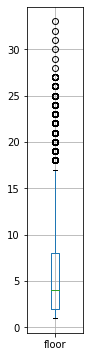

In [42]:
#Построим диаграмму размаха
data.boxplot(column='floor', grid=True, figsize=(1, 6))

#Судя по диаграмме значения более 27 являются редкими, и их можно отбросить.

In [43]:
data = data.query('floor <= 27').reset_index(drop=True)

Проанализируем столбец living_area:

In [44]:
data.living_area.describe()

count    23548.000000
mean        34.184752
std         20.282314
min          2.000000
25%         19.000000
50%         30.000000
75%         42.000000
max        255.700000
Name: living_area, dtype: float64

<AxesSubplot:>

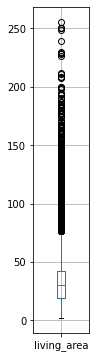

In [45]:
#Построим диаграмму размаха
data.boxplot(column='living_area', grid=True, figsize=(1, 6))

Судя по диаграмме значения более 200 являются редкими, и их можно отбросить.

In [46]:
data = data.query('living_area <= 200').reset_index(drop=True)

Проанализируем столбец kitchen_area:

In [47]:
data.kitchen_area.describe()

count    23533.000000
mean        10.404395
std          5.652018
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        107.000000
Name: kitchen_area, dtype: float64

<AxesSubplot:>

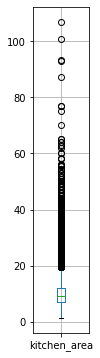

In [48]:
#Построим диаграмму размаха
data.boxplot(column='kitchen_area', grid=True, figsize=(1, 6))

Судя по диаграмме значения более 80 являются редкими, и их можно отбросить.

In [49]:
data = data.query('kitchen_area <= 80').reset_index(drop=True)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23528 entries, 0 to 23527
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23528 non-null  int64         
 1   last_price            23528 non-null  float64       
 2   total_area            23528 non-null  float64       
 3   first_day_exposition  23528 non-null  datetime64[ns]
 4   rooms                 23528 non-null  int64         
 5   ceiling_height        23528 non-null  float64       
 6   floors_total          23528 non-null  float64       
 7   living_area           23528 non-null  float64       
 8   floor                 23528 non-null  int64         
 9   is_apartment          23528 non-null  bool          
 10  studio                23528 non-null  bool          
 11  open_plan             23528 non-null  bool          
 12  kitchen_area          23528 non-null  float64       
 13  balcony         

In [51]:
old_data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [52]:
#Проверим сколько данных осталось
data.shape[0] / old_data.shape[0]

0.9927845056753449

Отлично - избавились от выбросов и потеряли менее 1% данных при этом.

In [53]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5528
city_centers_nearest     5507
parks_around_3000        5506
parks_nearest           15540
ponds_around_3000        5506
ponds_nearest           14528
days_exposition          3154
dtype: int64

Остальные пропуски трогать не будем, т.к. неясно чем их заполнить. В столбцах parks_around_3000, ponds_around_3000 и city_centers_nearest одинаковое и почти одинаковое количество пропусков, что говорит о том, что скорее всего был какой-то технический сбой при загрузке данных.

### Добавьте в таблицу новые столбцы

In [54]:
#Цена за квадратный метр
data['price_meter'] = data.last_price / data.total_area

In [55]:
#День недели публикации объявления
data['exposition_weekday'] = data.first_day_exposition.dt.weekday

In [56]:
#Для анализа месяцев публикации объявлений (в целом по всем годам) создадим столбец exposition_month:

data['exposition_month'] = data.first_day_exposition.dt.month
data['exposition_month'].head()

0     3
1    12
2     8
3     7
4     6
Name: exposition_month, dtype: int64

In [57]:
#Для анализа месяцев в каждом конкретном году создадим столбец exposition_month_of_the_year:

data['exposition_month_of_the_year'] = data['first_day_exposition'].dt.to_period('M')
data['exposition_month_of_the_year'].head()

0    2019-03
1    2018-12
2    2015-08
3    2015-07
4    2018-06
Name: exposition_month_of_the_year, dtype: period[M]

In [58]:
#Год публикации объявления
data['exposition_year'] = data.first_day_exposition.dt.year

In [59]:
#Создадим функцию определяющую тип этажа квартиры:
def get_floor_type(row):
    if row['floor'] == 1:
        return "первый"
    elif row['floor'] == row['floors_total']:
        return "последний"
    else:
        return "другой"


In [60]:
#Применим функцию создавая новый столбец
data['floor_type'] = data.apply(get_floor_type, axis=1)

In [61]:
#Расстояние до центра города в километрах:
data['km_to_city_center'] = round(data.city_centers_nearest / 1000)

### Проведите исследовательский анализ данных

Изучим параметры объектов недвижимости:

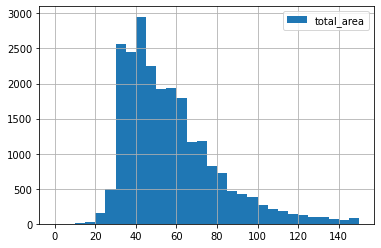

In [62]:
#Данные по общей площади:
data['total_area'].hist(bins=30, range=(0,150),legend='total_area')
plt.show()

В датасете преобладают объекты общей площадью 40-45 кв.м.

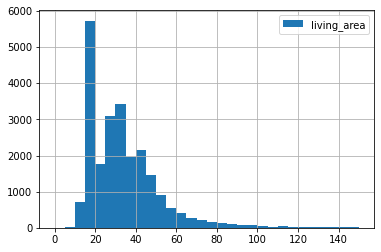

In [63]:
#Данные по жилой площади:
data['living_area'].hist(bins=30, range=(0,150),legend='living_area')
plt.show()

Больше всего объектов с жилой площадью 15-20 кв.м., а есть даже объекты с жилой площадью менее 10 кв.м.

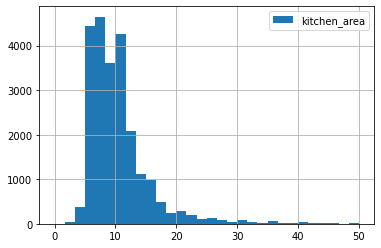

In [64]:
#Данные по площади кухни:
data['kitchen_area'].hist(bins=30, range=(0,50),legend='kitchen_area')
plt.show()

Чаще всего встречается площадь кухни 5-12 кв. м., при этом присутствуют кухни с площадью менее 5 кв.м и более 40.

In [65]:
#Создадим копию датасета для работы с гистограмой
data_mln = data.copy()
#Разделим цену на миллион для удобства отображения
data_mln['last_price']=data_mln['last_price']/1000000

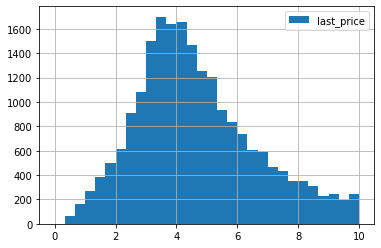

In [66]:
#Данные по цене объекта:
data_mln['last_price'].hist(bins=30, range=(0,10), legend='last_price')
plt.show()

Наиболее частая цена объекта 3,5-5 млн.руб.

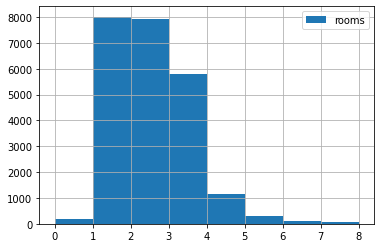

In [67]:
#Данные по количеству комнат:
data['rooms'].hist(bins=8, range=(0,8),legend='rooms')
plt.show()

Больше всего проедается квартир с количеством комнат 1 и 2.

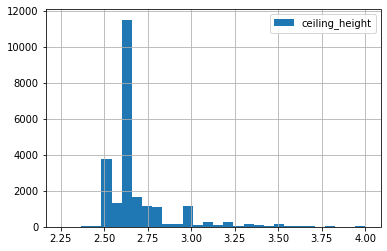

In [68]:
#Данные по высоте потолков:
data['ceiling_height'].hist(bins=30, range=(2.25,4),legend='ceiling_height')
plt.show()

Чаще сего встречаются высоты потолков 2,5 и 2,6 м, что соответствуем двум самым популярным классам объектов недвижимости.

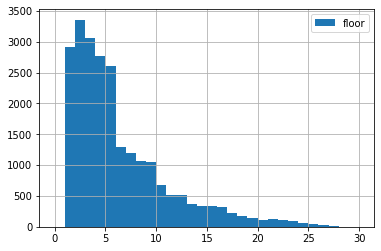

In [69]:
#Данные по этажу квартиры:
data['floor'].hist(bins=30, range=(0,30),legend='floor')
plt.show()

Судя по гистограмме, чаще всего продавались объекты высотой до 6 этажа.

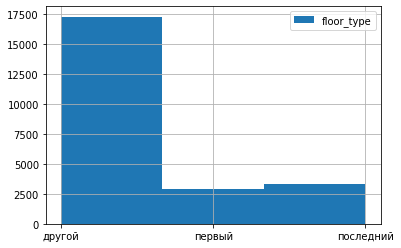

In [70]:
#Данные по типу этажа квартиры:
data['floor_type'].hist(bins=3,legend='floor_type')
plt.show()

Большая часть продаваемых квартир расположена ни на первых ни на последних этажах, первые и последние этаже продаются реже.

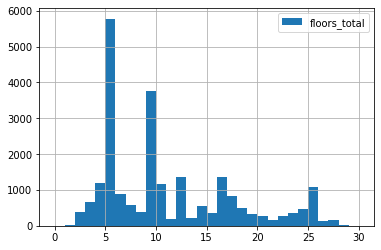

In [71]:
#Данные по общему количеству этажей в доме:
data['floors_total'].hist(bins=30,range=(0,30),legend='floors_total')
plt.show()

Наибольшее число квартир продавалось в 5-этажных домах и 9-этажных.

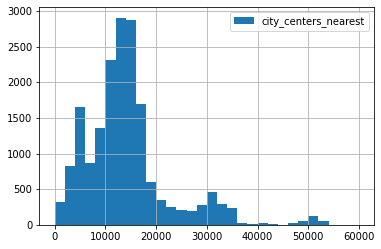

In [72]:
#Данные по расстоянию до центра города в метрах:
data['city_centers_nearest'].hist(bins=30, range=(0,60000), legend='city_centers_nearest')
plt.show()

Чаще всего продавались квартиры в домах, удаленных от центра на 12-16 км.

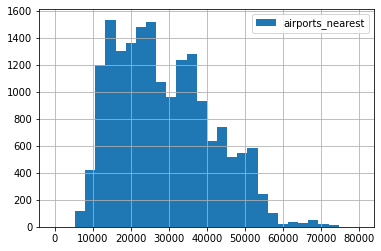

In [73]:
#Данные по расстоянию до ближайшего аэропорта:
data['airports_nearest'].hist(bins=30, range=(0,80000), legend='airports_nearest')
plt.show()

Удаленность объектов недвижимости от аэропортов сильно разбросана, но все же преобладают объекты с расстоянием до аэропорта 12-14 км.

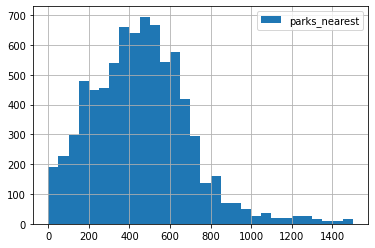

In [74]:
#Данные по расстоянию до ближайшего парка:
data['parks_nearest'].hist(bins=30, range=(0,1500),legend='parks_nearest')
plt.show()

Самое распространённое расстояние до парка среди продаваемых объектов составляет 450 м.

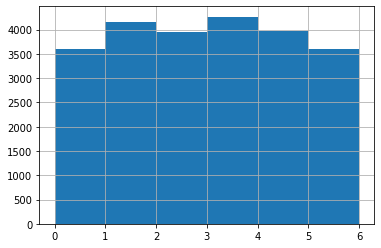

In [75]:
#Данные по дню публикации объявлений:
data['exposition_weekday'].hist(bins=6)
plt.show()

Размещение объявлений по дням недели происходило приблизительно равномерно с небольшим преобладанием в четверг.

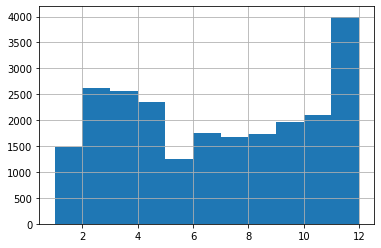

In [76]:
#Данные по месяцу публикации объявлений:
data['exposition_month'].hist(bins=11)
plt.show()

Больше всего объявлений опубликовано в последний месяц года.

Вывод по п. 4:
Проанализоровав данные таблицы, можно сделать вывод о наиболее продаваемом объекте недвижимости: это 1-2 комнатная квартира на 2-м этаже 5-этажного дома общей площадью около 45 кв.м. с жилой площадью 15-20 кв.м. и площадью кухни около 8 кв.м., стоимостью 3,5-5 млн.руб. и высотой потолков 2,6 м., удаленная от центра на 12-16 км., от парка на 450 м и от аэропорта на 12-14 км. А в конце года происходил резкий рост количества объявления о продаже.

Анализ скорости продажи квартир

Построим гистограмму по данным столбца days_exposition, показывающего сколько дней было размещено объявление:

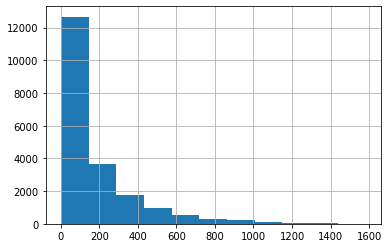

In [77]:
data['days_exposition'].hist(bins=11)
plt.show()

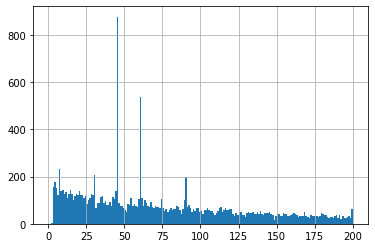

In [78]:
#Для более наглядного отображения изменим масштаб отображения гистограммы и увеличим количество корзин:

data['days_exposition'].hist(bins=200, range=(0, 200))
plt.show()

In [79]:
#На диаграмме обнаружились аномалии, найдем их зачения:

data['days_exposition'].value_counts().head(10)

45.0    878
60.0    538
7.0     233
30.0    208
90.0    200
4.0     176
3.0     157
5.0     151
14.0    145
9.0     142
Name: days_exposition, dtype: int64

Чаще всего объекты продавались на 45-й и 60-й день после подачи объявлений.

Посчитаем среднее и медиану по данным столбца days_exposition:

In [80]:
data['days_exposition'].describe()

count    20374.000000
mean       180.520124
std        219.255701
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64

Среднее время продажи квартиры составляет 180 дней. Медианное значение составляет 95 дней, что сильно отличается от среднего, такие продажи можно назвать быстрыми. Чаще всего объекты продавались на 45-й и 60-й день после подачи объявления. При этом в наборе данных присутствуют необычно долгие продажи длившиеся 4 года и более.

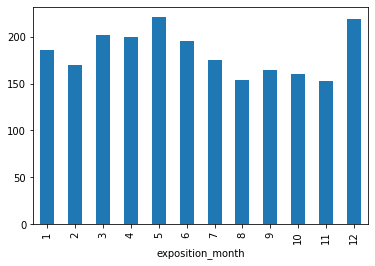

In [81]:
#Для более детальной оценки скорости продажи можно оценить ее в зависмости от других факторов, например, от месяца подачи объявления:
data.groupby('exposition_month')['days_exposition'].mean().plot.bar()
plt.show()

Видим, что быстрее всего продавались квартиры, размещенные в объявлениях в ноябре, а медленнее всего - размещенные в мае.

Изучим факторы, влияющие на общую (полную) стоимость объекта

Проанализируем зависимость цены от общей площади объекта:

Построим диаграмму рассеяния:

<AxesSubplot:xlabel='total_area', ylabel='last_price'>

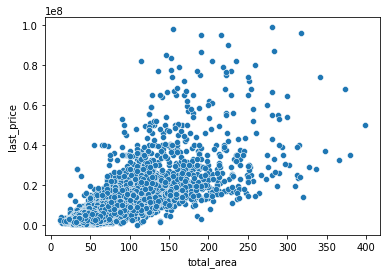

In [82]:
seaborn.scatterplot(x='total_area', y='last_price', data=data)

Построим диаграмму рассеяния с линией регрессии:

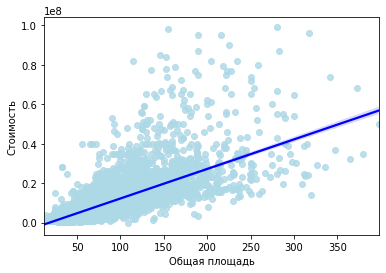

In [83]:
seaborn.regplot(
    x='total_area',
    y='last_price',
    data=data, scatter_kws={"color": "lightblue"}, line_kws={"color": "blue"})
plt.xlabel(
    'Общая площадь')
plt.ylabel(
    'Стоимость')
plt.show()

Из диаграммы видно, что с ростом общей площади растет и цена, при этом также увеличивается разброс цен на объекты одинаковой площади.

Для оценки корреляции рассчитаем коэффициент Пирсона:

In [84]:
round(data['total_area'].corr(data['last_price']), 2)

0.76

Проанализируем зависимость цены от жилой площади объекта:

Построим диаграмму рассеяния с линией регрессии:

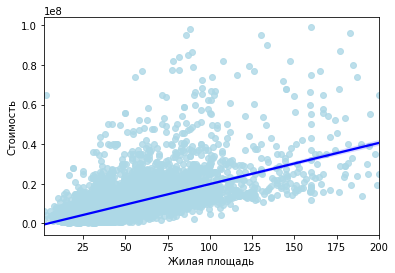

In [85]:
seaborn.regplot(
    x='living_area',
    y='last_price',
    data=data, scatter_kws={"color": "lightblue"}, line_kws={"color": "blue"})
plt.xlabel(
    'Жилая площадь')
plt.ylabel(
    'Стоимость')
plt.show()

In [86]:
#Для оценки корреляции рассчитаем коэффициент Пирсона:

round(data['living_area'].corr(data['last_price']), 2)

0.67

Из диаграммы видно, что с ростом жилой площади растет и цена, при этом также увеличивается разброс цен на объекты с одинаковой жилой площадью. Однако рассчитанный коэффциент корреляции ниже, чем аналогичный коэффициент для общей площади.



Проанализируем зависимость цены от площади кухни объекта:
Построим диаграмму рассеяния с линией регрессии:

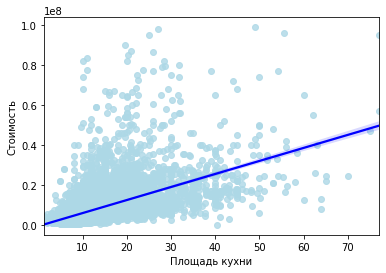

In [87]:
seaborn.regplot(
    x='kitchen_area',
    y='last_price',
    data=data, scatter_kws={"color": "lightblue"}, line_kws={"color": "blue"})
plt.xlabel(
    'Площадь кухни')
plt.ylabel(
    'Стоимость')
plt.show()

In [88]:
#Для оценки корреляции рассчитаем коэффициент Пирсона:

round(data['kitchen_area'].corr(data['last_price']), 2)

0.59

Из диаграммы видно, что с ростом площади кухни растет и цена, однако рассчитанный коэффциент корреляции ниже, чем аналогичный коэффициент для общей площади.


Проанализируем зависимость цены от количества комнат объекта:
    
Построим диаграмму рассеяния с линией регрессии:

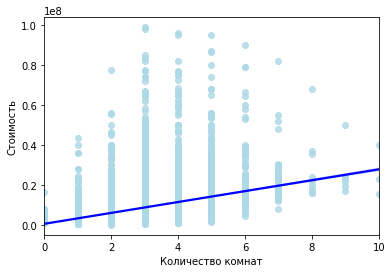

In [89]:
seaborn.regplot(
    x='rooms',
    y='last_price',
    data=data, scatter_kws={"color": "lightblue"}, line_kws={"color": "blue"})
plt.xlabel(
    'Количество комнат')
plt.ylabel(
    'Стоимость')
plt.show()

In [90]:
#Для оценки корреляции рассчитаем коэффициент Пирсона:

round(data['rooms'].corr(data['last_price']), 2)

0.47

Из диаграммы видно, что с ростом количества комнат растет и цена, однако рассчитанный коэффциент корреляции ниже, чем аналогичный коэффициент для общей площади. На объекты с количеством комнат 3, 4 и 5 наблюдается наибольший разброс цен.



Проанализируем зависимость цены от этажа, на котором расположена квартира (первый, последний, другой):

Построим гистограмму:

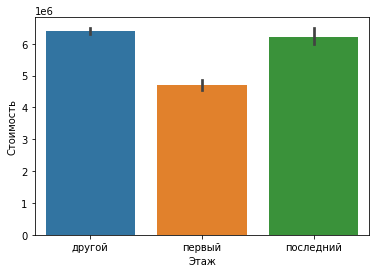

In [91]:
seaborn.barplot(
    x='floor_type',
    y='last_price',
    data=data)
plt.xlabel(
    'Этаж')
plt.ylabel(
    'Стоимость')
plt.show()

Из гистограммы видно, что самая низкая цена у квартир на первом этаже, а выше всего цены на квартиры, находящиеся ни на первом, ни на последнем этаже.


Проанализируем зависимость цены от дня недели размещения объявления:
    
Построим гистограмму:

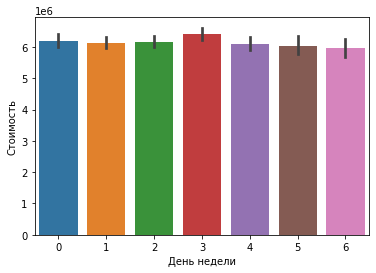

In [92]:
seaborn.barplot(
    x='exposition_weekday',
    y='last_price',
    data=data)
plt.xlabel(
    'День недели')
plt.ylabel(
    'Стоимость')
plt.show()

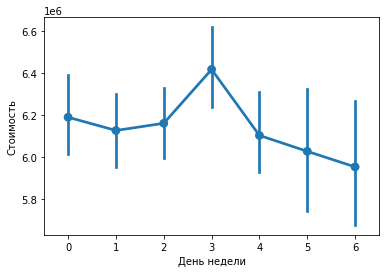

In [93]:
#Для большей наглядности построим точечную диаграмму:
seaborn.pointplot(
    x='exposition_weekday',
    y='last_price',
    data=data)
plt.xlabel(
    'День недели')
plt.ylabel(
    'Стоимость')
plt.show()

Из диаграммы видно, что дороже всего продавались квартиры, размещенные в объявлениях по четвергам.

Проанализируем зависимость цены от месца размещения объявления:
    
Построим гистограмму:

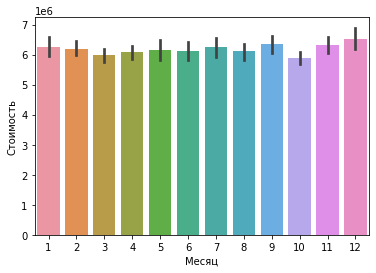

In [94]:
seaborn.barplot(
    x='exposition_month',
    y='last_price',
    data=data)
plt.xlabel(
    'Месяц')
plt.ylabel(
    'Стоимость')
plt.show()

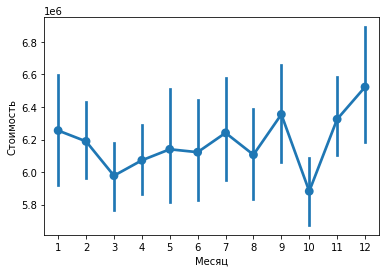

In [95]:
#Для большей наглядности построим точечную диаграмму:

seaborn.pointplot(
    x='exposition_month',
    y='last_price',
    data=data)
plt.xlabel(
    'Месяц')
plt.ylabel(
    'Стоимость')
plt.show()

Из диаграммы видно, что дешевле всего продавались квартиры, размещенные в объявлениях в октябре, а дороже всего - размещенные в декабре.

Проанализируем зависимость цены от года размещения объявления:
    
Построим гистограмму:

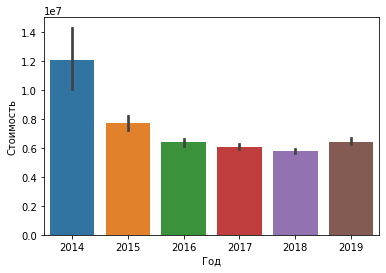

In [96]:
seaborn.barplot(
    x='exposition_year',
    y='last_price',
    data=data)
plt.xlabel(
    'Год')
plt.ylabel(
    'Стоимость')
plt.show()

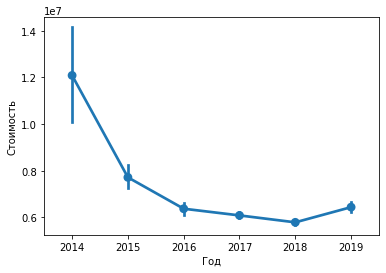

In [97]:
#Для большей наглядности построим точечную диаграмму:

seaborn.pointplot(
    x='exposition_year',
    y='last_price',
    data=data)
plt.xlabel(
    'Год')
plt.ylabel(
    'Стоимость')
plt.show()


Из диаграммы видно, что с 2014 года цены на квартиры падали, в 2018 году была самая низкая цена продаж, после чего цены вновь начали расти. Но на уменьшение стоимости квартир могло повлиять уменьшение их площади. Проверим это предположение, проанализировав зависимость площади и цены квадратного метра от года размещения объявления:

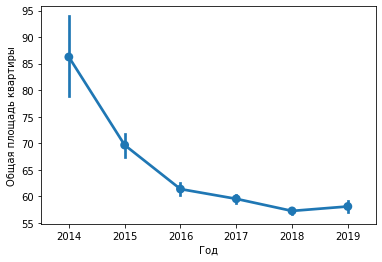

In [98]:
seaborn.pointplot(
    x='exposition_year',
    y='total_area',
    data=data)
plt.xlabel(
    'Год')
plt.ylabel(
    'Общая площадь квартиры')
plt.show()

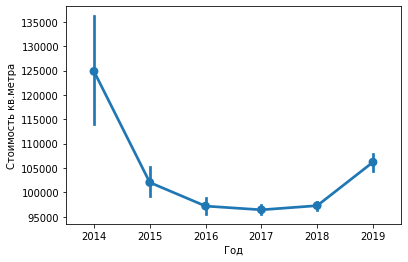

In [99]:
seaborn.pointplot(
    x='exposition_year',
    y='price_meter',
    data=data)
plt.xlabel(
    'Год')
plt.ylabel(
    'Стоимость кв.метра')
plt.show()

Действительно, в 2018 г были минимальные площади продаваемых квартир, что обусловило и минимальные цены на объекты недвижимости. Проверив динамику стоимости квадратного метра, обнаружили, что в 2017- 2018 гг стоимость квадратного метра стала минимальной, после чего, вероятно, стало невыгодно продавать квартиры с большой площадью, и площадь продаваемых объектов в 2018 году упала до минимума.

Проанализируем цену одного квадратного метра
Посчитаем медианную цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений:

In [100]:
median_prices = data.groupby('locality_name')['price_meter']\
                        .agg(['count','median'])\
                        .sort_values(by='count', ascending=False).head(10)
median_prices

,count,median
locality_name,,
Санкт-Петербург,15568,104686.721087
Мурино,586,86250.377687
Кудрово,470,95555.311677
Шушары,439,76829.268293
Всеволожск,398,65789.473684
Пушкин,368,99993.589744
Колпино,338,74723.748474
Парголово,327,91642.857143
Гатчина,307,67796.610169


In [101]:
#Населенный пункт с минимальной стоимостью квадратного метра (среди 10-ти н.п. с наибольшим количеством объявлений):
median_prices[median_prices['median'] == median_prices['median'].min()]

,count,median
locality_name,,
Выборг,237,58158.319871


In [102]:
#Населенный пункт с максимальной стоимостью квадратного метра (среди 10-ти н.п. с наибольшим количеством объявлений):
median_prices[median_prices['median'] == median_prices['median'].max()]

,count,median
locality_name,,
Санкт-Петербург,15568,104686.721087


Выделим цветом максимальную и минимальную стоимости квадратного метра среди 10 населенных пунктов с наибольшим количесвом объявлений, построив температурный график (синий - минимальный, красный - максимальный):

In [103]:
pd.DataFrame(median_prices['median'].to_frame(name='Цена кв.м.')).style.background_gradient('coolwarm')

,Цена кв.м.
locality_name,
Санкт-Петербург,104686.721087
Мурино,86250.377687
Кудрово,95555.311677
Шушары,76829.268293
Всеволожск,65789.473684
Пушкин,99993.589744
Колпино,74723.748474
Парголово,91642.857143
Гатчина,67796.610169


Вывод:
Среди 10 населенных пунктов с наибольшим количеством объявлений максимальная стоимость квадратного метра наблюдается в Санкт-Петербурге, минимальная - в Выборге.

In [104]:
#Проанализируем стоимость объектов в зависимости от расстояния до центра в километрах:
prices_km_to_center = data.query('locality_name == "Санкт-Петербург"')\
        .pivot_table(index='km_to_city_center', values='price_meter')
prices_km_to_center

,price_meter
km_to_city_center,
0.0,228257.448843
1.0,154823.371621
2.0,148437.379145
3.0,121133.014336
4.0,128506.326593
5.0,137340.036472
6.0,144761.518728
7.0,153541.381283
8.0,125169.601729


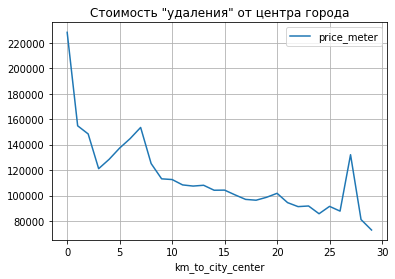

In [105]:
#Построим график:

prices_km_to_center.plot(grid=True, title = 'Cтоимость "удаления" от центра города')
plt.show()

Вывод:
В целом с удалением от центра Санкт-Петербурга стоимость квадратного метра уменьшается. Однако на удаленности 7 км и 27 км от центра наблюдается рост цен квадратного метра, это может быть связано с нахождением там КАД или элитных жилых районов.

Общий вывод

Для исследования объявлений о продаже квартир мы проанализировали данные сервиса Яндекс.Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктов за несколько лет.
Объем данных до предобработки составлял 23699 строк, а после удаления аномальных значений 23528 строк. Были отброшены или в некоторых случаях заменены на невыбивающиеся данные о квартирах стоимостью более 100 млн, общей площадью более 400 кв.м. с числом комнат более 10, высотой потолков более 10 м. и менее 2 м, располагающиеся выше 27 этажа, в домах высотой более 40 этажей, с жилой площадью более 200 кв.м. И площадью кухни более 80 кв.м. В процессе обработки обнаружили наибольшее количество пропусков в столбце is_apartment. Проанализировав строки с пропусками, сделали следующие предположения: пропуски в столбце is_apartment, вероятно, связаны с тем, что данные объекты недвижимости не являются апартаментами, такие пропуски заменили на False. Пропуски в графе balcony, вероятно, связаны с тем, что в данных объектах недвижимости нет балконов, их заменили нулями. Пропуски в графе «Жилая площадь» заполнили отношением средней из имеющихся данных в этом столбце к средней общей площади из имеющихся данных, т.к. наибольшая корреляция была именно с общей площадью. Пропуски в графе «Площадь кухни» заменили отношением средней из имеющихся данных в этом столбце к средней общей площади из имеющихся данных, т.к. наибольшая корреляция была именно с общей площадью. Пропуски высоты потолков заполнили медианным значением. Пропуски в графах «Название н.п.» и «Общее кол-во этажей» пропустили, т.к. они составляли малую долю в общих данных. Изменили типы данных в столбцах first_day_exposition, balcony, locality_name  - для удобства последующего анализа. Далее выполнили поиск дубликатов и заменили разные написания названий одних и тех же населенных пунктов - на единые.
Затем посчитали и добавили в таблицу данные о стоимости одного квадратного метра, дне недели, месяце и годе публикации объявления, типе этажа квартиры и расстоянии до центра города в км.

Далее провели исследовательский анализ данных:
Изучив параметры объектов недвижимости, сделали вывод о наиболее продаваемом объекте недвижимости: это 1-2 комнатная квартира на 2-м этаже 5-этажного дома общей площадью 40-45 кв.м. с жилой площадью 15-20 кв.м. и площадью кухни около 8 кв.м., стоимостью 3,5-5 млн.руб. и высотой потолков 2,6 м., удаленная от центра на 12-16 км., от парка на 450 м и от аэропорта на 12-14 км. В конце года происходил резкий рост количества объявления о продаже.
Проведя анализ скорости продажи квартир, обнаружили, что среднее время продажи квартиры составляет 180 дней. Медианное значение составляет 95 дней, что сильно отличается от среднего. Чаще всего объекты продавались за 45 или 60 дней, точнее сказать нельзя т.к. скорее всего на ресурсе присутствуют какие-то правила, что чаще всего объявления закрываются именно в эти дни. При этом в наборе данных присутствуют необычно долгие продажи в течение 4-х лет и более. Также обнаружили, что быстрее всего продавались квартиры, размещенные в объявлениях в ноябре, а медленнее всего - размещенные в мае.
Изучив факторы, влияющие на стоимость объекта, выяснили что больше всего на стоимость влияет полная площадь объектов. При этом самая низкая цена у квартир на первом этаже, а выше всего у квартир находящихся ни на первом ни на последнем этаже. Также дороже всего продавались квартиры, размещенные в объявлениях по четвергам в декабре, а дешевле всего - в октябре. Кроме того выяснили, что с 2014 года цены на квартиры падали, в 2018 году была самая низкая цена продаж, после чего цены вновь начали расти. Но падение стоимости квартир было обусловлено тем, что в 2018 г. были минимальные площади продаваемых объектов. Проверив динамику стоимости квадратного метра, обнаружили, что в 2017- 2018 гг стоимость квадратного метра стала минимальной, после чего, вероятно, стало невыгодно продавать квартиры с большой площадью, и площадь продаваемых объектов в 2018 году упала до минимума.
Проанализировав цену одного квадратного метра, выяснили, что среди 10 населенных пунктов с наибольшим количеством объявлений максимальная стоимость квадратного метра наблюдается в Санкт-Петербурге, минимальная - в Выборге.
Проанализировав стоимость объектов в зависимости от расстояния до центра в километрах убедились, что в целом с удалением от центра Санкт-Петербурга стоимость квадратного метра уменьшается. Однако на удаленности 7 км и 27 км от центра наблюдается рост цен квадратного метра, это может быть связано с нахождением там КАД или элитных жилых районов.